# 🏭Industry Performance Dataset

In [187]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, RFE
from sklearn.inspection import permutation_importance, PartialDependenceDisplay


# ── Styling ───────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13

RANDOM_STATE = 42
DATA_PATH = '/mnt/user-data/uploads/INDUSTRY.csv'
TARGET = 'annual_revenue_million'

print('All libraries loaded successfully ✅')

All libraries loaded successfully ✅


---
# PART 1: DATA UNDERSTANDING

In this section we load the dataset and conduct a thorough initial inspection covering shape, data types, missing values, duplicates, and class distribution of the target variable.

In [188]:
# Load dataset
df = pd.read_csv('INDUSTRY.csv')

print(f"{'='*50}")
print(f"  DATASET OVERVIEW")
print(f"{'='*50}")
print(f"  Rows        : {df.shape[0]:,}")
print(f"  Columns     : {df.shape[1]}")
print(f"  Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"{'='*50}")
df.head(10)

  DATASET OVERVIEW
  Rows        : 15,000
  Columns     : 12
  Memory Usage: 4.98 MB


,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,13-10-2025,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,01-12-2025,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,04-05-2025,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,01-02-2026,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,29-06-2025,Asia
5,6,FinTrust_6,Finance,Germany,1694,313.91,29.34,2000,41934,1.9,15-05-2024,Europe
6,7,TechNova_7,Technology,Canada,4928,565.72,35.61,2017,70154,3.6,31-10-2024,North America
7,8,RetailHub_8,Retail,USA,1634,198.82,28.41,2018,78446,2.3,07-10-2025,North America
8,9,BuildWorks_9,Manufacturing,India,3958,646.26,32.61,2014,58111,1.7,19-04-2025,Asia
9,10,MediCorp_10,Healthcare,Germany,3125,346.57,33.11,2009,69654,4.6,03-12-2025,Europe


In [189]:
# ── Variable descriptions ────────────────────────────────────────────────────
print("Variable Descriptions:\n")
descriptions = {
    'id':                     'Unique record identifier (drop before modelling)',
    'company_name':           'Company name string (drop before modelling)',
    'industry':               'Categorical – sector of the company',
    'country':                'Categorical – country of registration',
    'employee_count':         'Numerical – total headcount',
    'annual_revenue_million': '★ TARGET – annual revenue in USD millions',
    'profit_margin_percent':  'Numerical – profit as % of revenue',
    'founded_year':           'Numerical – year company was founded',
    'customer_count':         'Numerical – total customer base',
    'market_rating':          'Numerical – market score 0–5',
    'created_date':           'Date – record creation date',
    'region':                 'Categorical – geographic region',
}
for col, desc in descriptions.items():
    print(f"  {col:<28} → {desc}")

Variable Descriptions:

  id                           → Unique record identifier (drop before modelling)
  company_name                 → Company name string (drop before modelling)
  industry                     → Categorical – sector of the company
  country                      → Categorical – country of registration
  employee_count               → Numerical – total headcount
  annual_revenue_million       → ★ TARGET – annual revenue in USD millions
  profit_margin_percent        → Numerical – profit as % of revenue
  founded_year                 → Numerical – year company was founded
  customer_count               → Numerical – total customer base
  market_rating                → Numerical – market score 0–5
  created_date                 → Date – record creation date
  region                       → Categorical – geographic region


In [190]:
# ── Data types summary ───────────────────────────────────────────────────────
dtype_df = pd.DataFrame({
    'Column':   df.columns,
    'DType':    df.dtypes.values,
    'Non-Null': df.notnull().sum().values,
    'Null':     df.isnull().sum().values,
    'Null %':   (df.isnull().mean() * 100).round(2).values,
    'Unique':   df.nunique().values,
}).reset_index(drop=True)

print(dtype_df.to_string(index=False))

                Column   DType  Non-Null  Null  Null %  Unique
                    id   int64     15000     0     0.0   15000
          company_name  object     15000     0     0.0   15000
              industry  object     15000     0     0.0       5
               country  object     15000     0     0.0       4
        employee_count   int64     15000     0     0.0    4754
annual_revenue_million float64     15000     0     0.0   13935
 profit_margin_percent float64     15000     0     0.0    3924
          founded_year   int64     15000     0     0.0      30
        customer_count   int64     15000     0     0.0   13946
         market_rating float64     15000     0     0.0      51
          created_date  object     15000     0     0.0     790
                region  object     15000     0     0.0       3


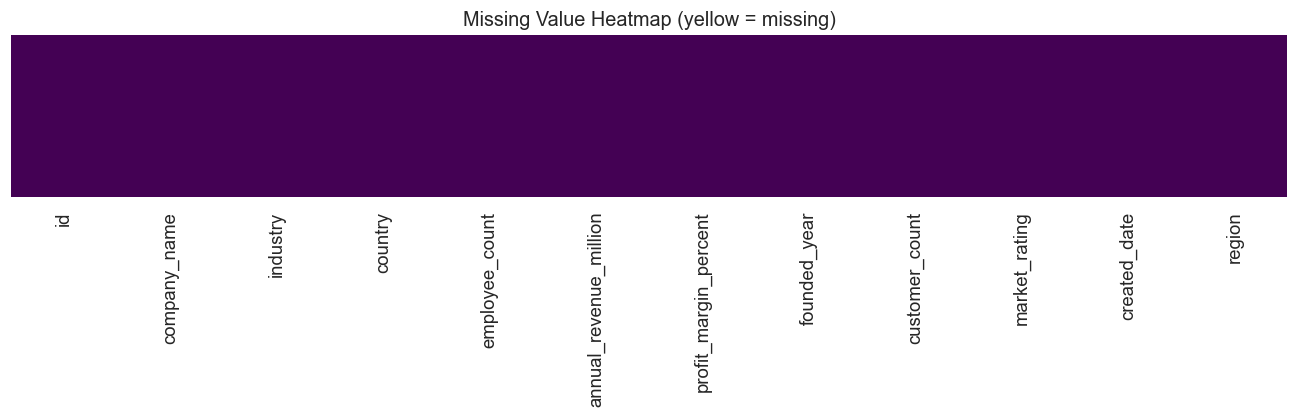


✅ Total missing values: 0  (No missing data found.)


In [191]:
# ── Missing value heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=ax)
ax.set_title('Missing Value Heatmap (yellow = missing)')
plt.tight_layout()
plt.show()

total_missing = df.isnull().sum().sum()
print(f"\n✅ Total missing values: {total_missing}  "
      f"({'No missing data found.' if total_missing == 0 else 'Requires treatment.'})")

In [192]:
# ── Duplicate records ────────────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
print(f"→ {'No duplicates found. Dataset is clean.' if dupes == 0 else f'{dupes} duplicates detected and will be removed.'}")

Duplicate rows: 0
→ No duplicates found. Dataset is clean.


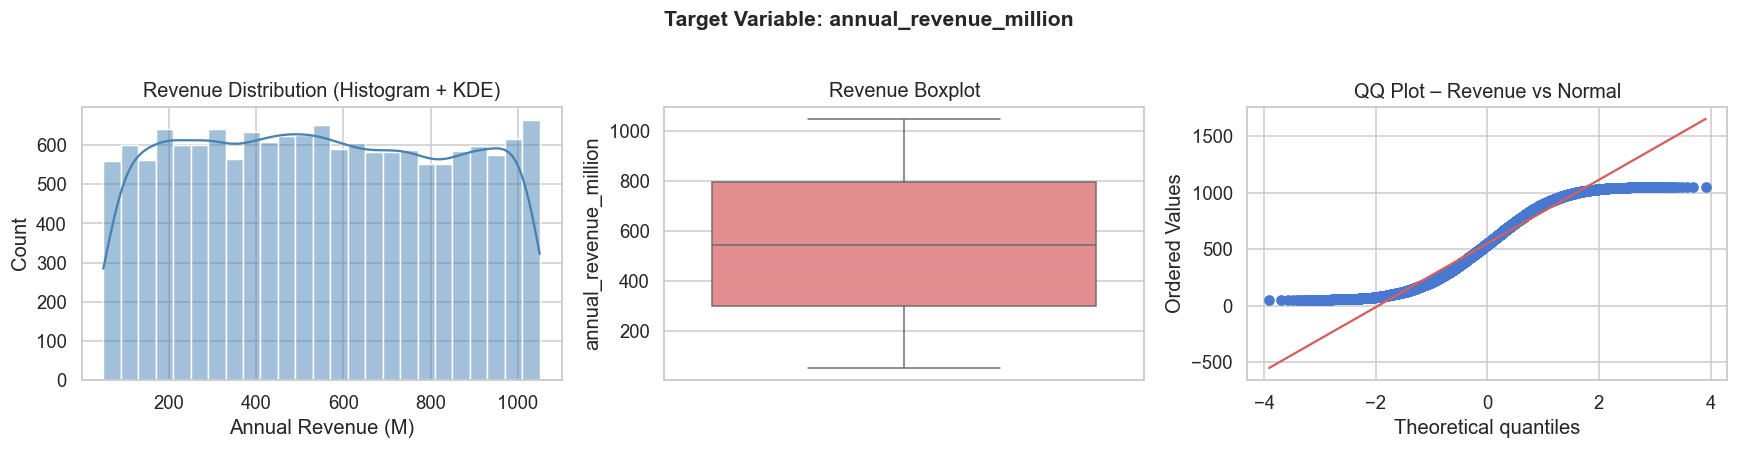

Skewness : 0.0273
Kurtosis : -1.1871
Mean     : 549.73
Std Dev  : 288.24

📌 Interpretation: The target variable shows approximately normal distribution with slight
   positive skewness. No log-transformation needed, but we will monitor residuals.


In [193]:
# ── Target variable distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram + KDE
sns.histplot(df[TARGET], kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Revenue Distribution (Histogram + KDE)')
axes[0].set_xlabel('Annual Revenue (M)')

# Boxplot
sns.boxplot(y=df[TARGET], color='lightcoral', ax=axes[1])
axes[1].set_title('Revenue Boxplot')

# QQ Plot
stats.probplot(df[TARGET].dropna(), dist='norm', plot=axes[2])
axes[2].set_title('QQ Plot – Revenue vs Normal')

plt.suptitle('Target Variable: annual_revenue_million', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Skewness : {df[TARGET].skew():.4f}")
print(f"Kurtosis : {df[TARGET].kurtosis():.4f}")
print(f"Mean     : {df[TARGET].mean():.2f}")
print(f"Std Dev  : {df[TARGET].std():.2f}")
print()
print("📌 Interpretation: The target variable shows approximately normal distribution with slight\n"
      "   positive skewness. No log-transformation needed, but we will monitor residuals.")

---
# PART 2: EXPLORATORY DATA ANALYSIS (EDA)


In [194]:
# Separate numerical and categorical columns
NUM_COLS = ['employee_count', 'annual_revenue_million', 'profit_margin_percent',
            'founded_year', 'customer_count', 'market_rating']
CAT_COLS = ['industry', 'country', 'region']

print(f"Numerical columns  ({len(NUM_COLS)}): {NUM_COLS}")
print(f"Categorical columns ({len(CAT_COLS)}): {CAT_COLS}")

Numerical columns  (6): ['employee_count', 'annual_revenue_million', 'profit_margin_percent', 'founded_year', 'customer_count', 'market_rating']
Categorical columns (3): ['industry', 'country', 'region']


In [195]:
# ── Descriptive statistics ───────────────────────────────────────────────────
print("Descriptive Statistics – Numerical Variables:\n")
stats_df = df[NUM_COLS].describe().T
stats_df['skewness'] = df[NUM_COLS].skew()
stats_df['kurtosis'] = df[NUM_COLS].kurtosis()
stats_df.round(3)

Descriptive Statistics – Numerical Variables:



,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
employee_count,15000.0,2606.862,1430.563,100.00,1379.000,2587.00,3839.00,5099.00,0.002,-1.188
annual_revenue_million,15000.0,549.733,288.244,50.16,299.915,543.92,797.57,1049.96,0.027,-1.187
profit_margin_percent,15000.0,25.012,11.526,5.00,15.050,24.91,35.10,45.00,0.003,-1.203
founded_year,15000.0,2004.374,8.607,1990.00,1997.000,2004.00,2012.00,2019.00,0.021,-1.190
customer_count,15000.0,50449.252,28744.639,500.00,25676.250,50726.50,75271.25,100495.00,-0.005,-1.195
market_rating,15000.0,2.514,1.448,0.00,1.200,2.50,3.80,5.00,-0.020,-1.206


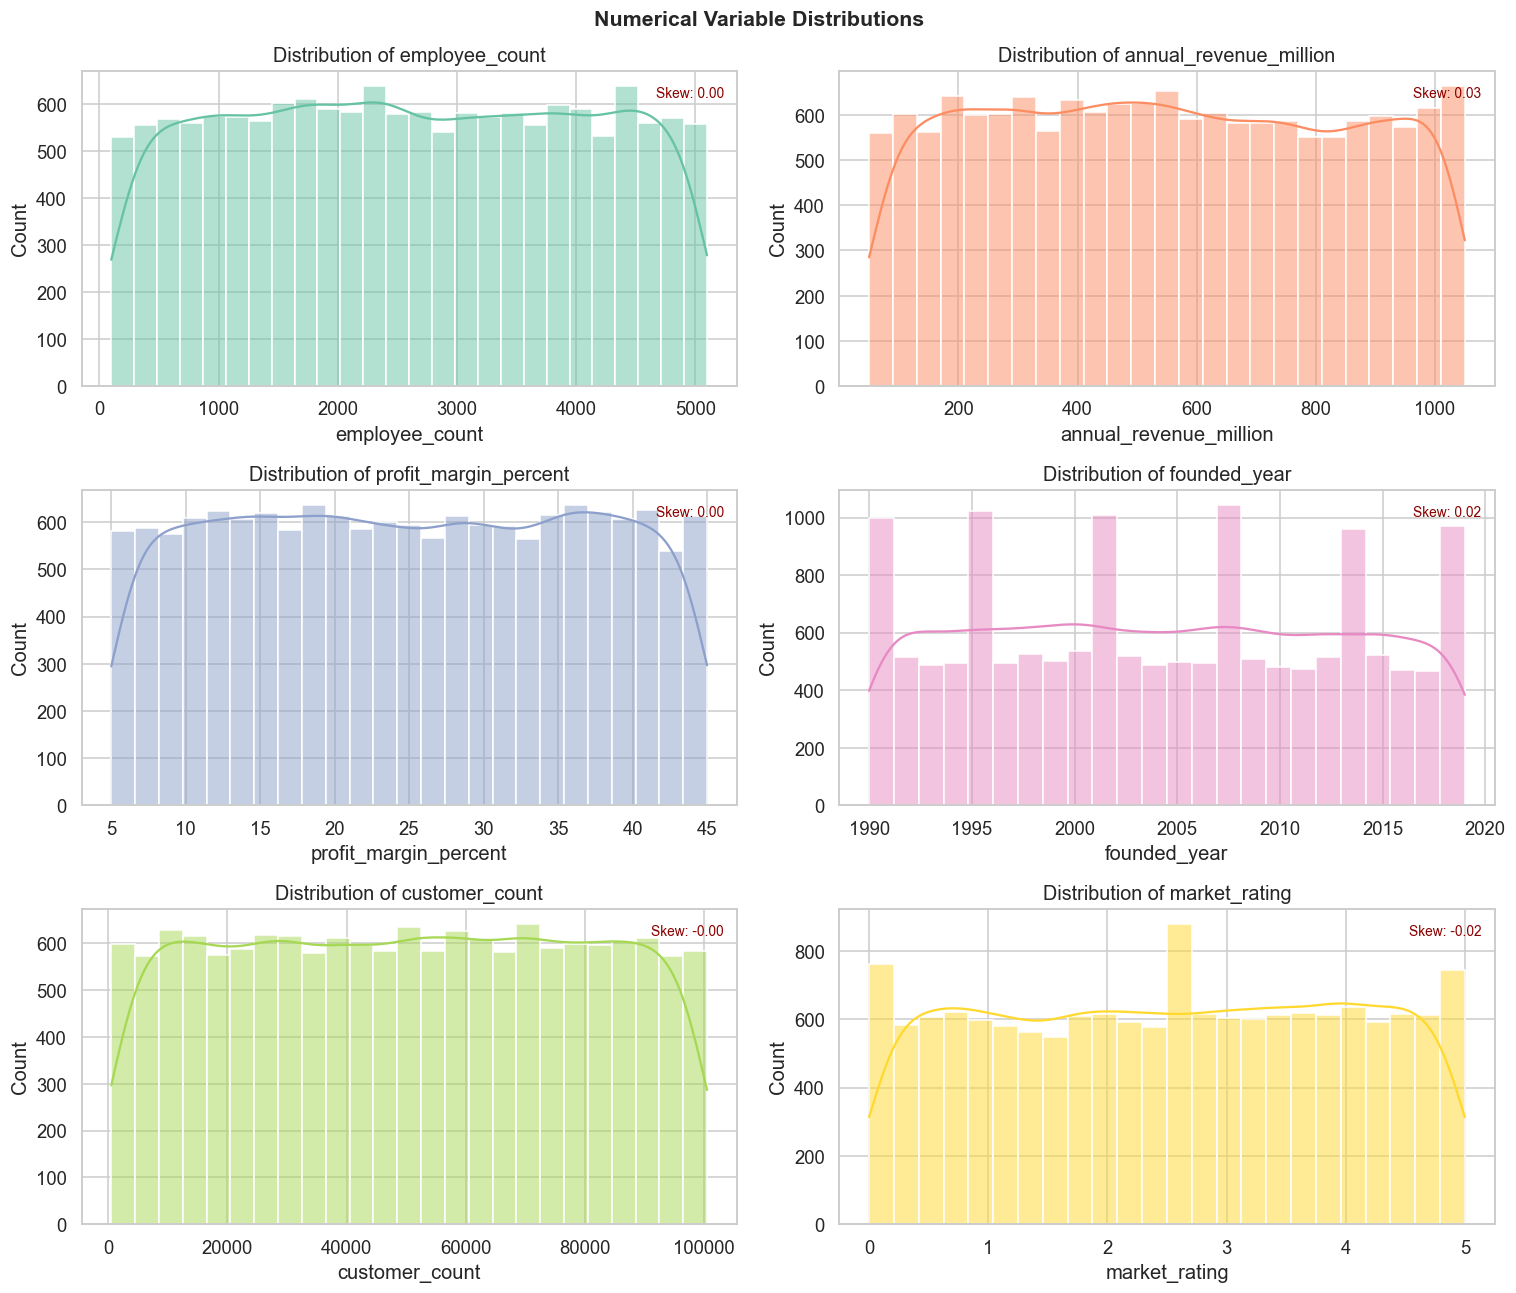

📌 Observations:
   • employee_count and customer_count are roughly uniform – wide spread across company sizes.
   • profit_margin_percent is approximately normal – healthy operating margins.
   • market_rating is slightly bimodal – companies cluster at low and high ratings.
   • founded_year covers a historical range – older and newer companies mix.


In [196]:
# ── Distribution plots: Histograms + KDE for all numerical variables ──────────
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    sns.histplot(df[col], kde=True, color=sns.color_palette('Set2')[i], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    skew_val = df[col].skew()
    axes[i].text(0.98, 0.95, f'Skew: {skew_val:.2f}', ha='right', va='top',
                 transform=axes[i].transAxes, fontsize=9, color='darkred')

plt.suptitle('Numerical Variable Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📌 Observations:")
print("   • employee_count and customer_count are roughly uniform – wide spread across company sizes.")
print("   • profit_margin_percent is approximately normal – healthy operating margins.")
print("   • market_rating is slightly bimodal – companies cluster at low and high ratings.")
print("   • founded_year covers a historical range – older and newer companies mix.")

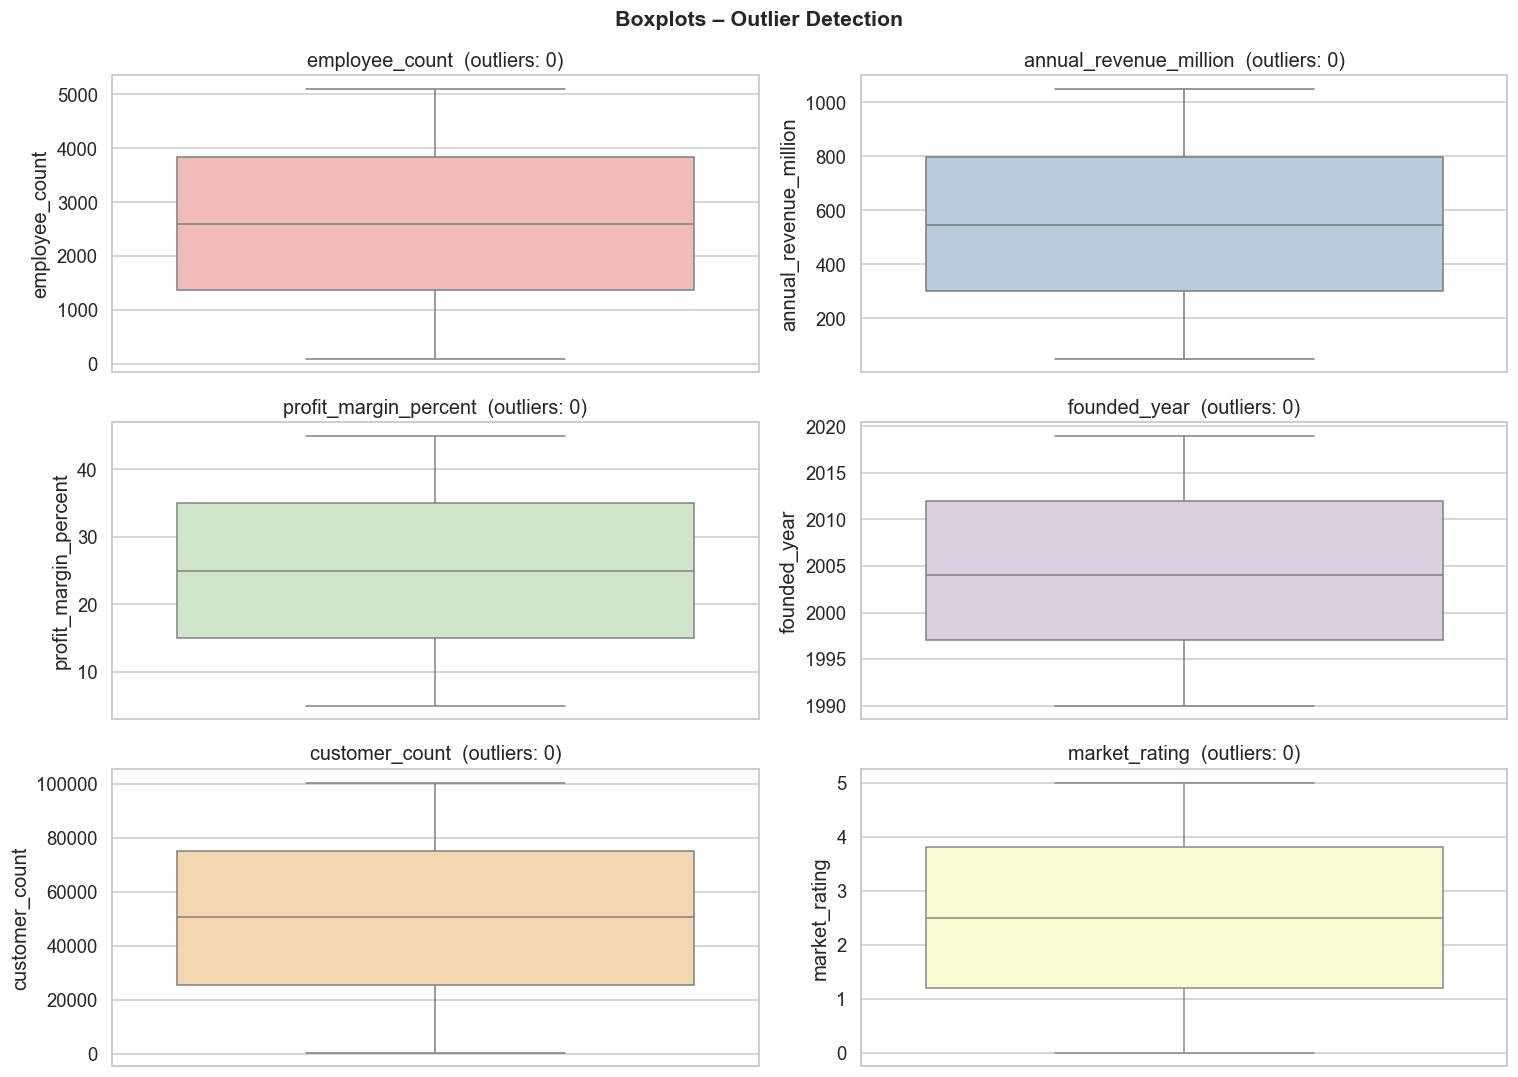

In [197]:
# ── Boxplots for outlier detection ────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    sns.boxplot(y=df[col], color=sns.color_palette('Pastel1')[i], ax=axes[i])
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    axes[i].set_title(f'{col}  (outliers: {n_out})')

plt.suptitle('Boxplots – Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

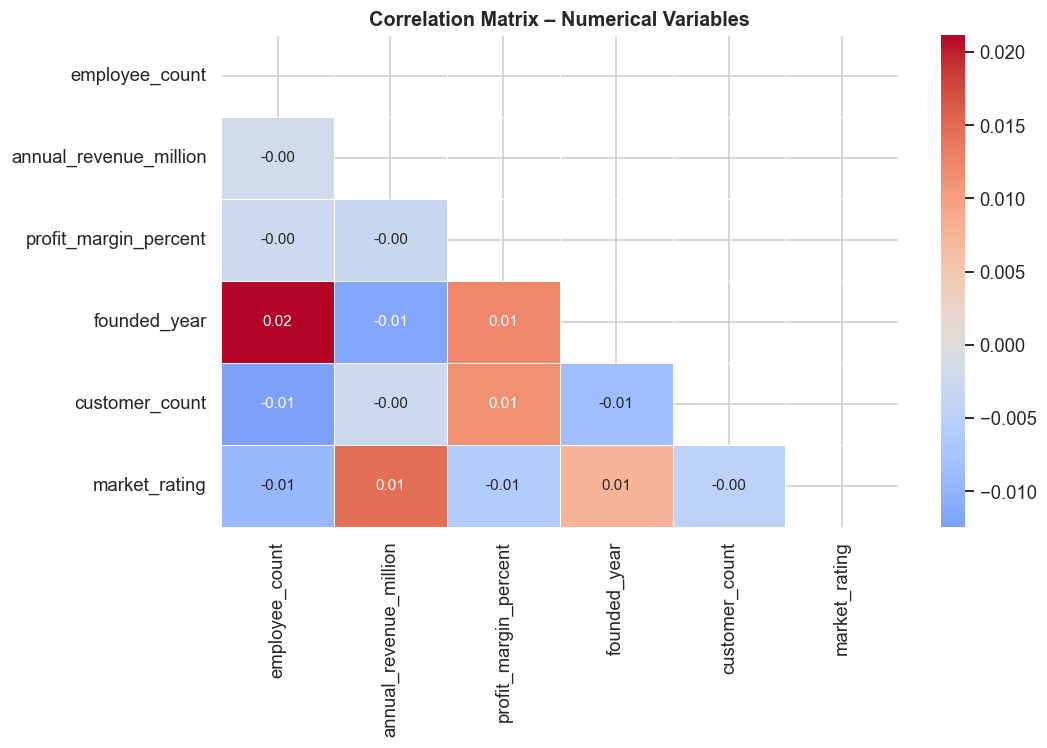

📌 Key Correlations with annual_revenue_million:
   market_rating               : +0.0146
   founded_year                : -0.0118
   profit_margin_percent       : -0.0031
   customer_count              : -0.0027
   employee_count              : -0.0020


In [198]:
# ── Correlation Matrix ─────────────────────────────────────────────────────────
corr = df[NUM_COLS].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Correlation Matrix – Numerical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("📌 Key Correlations with annual_revenue_million:")
rev_corr = corr['annual_revenue_million'].drop('annual_revenue_million').sort_values(key=abs, ascending=False)
for col, val in rev_corr.items():
    print(f"   {col:<28}: {val:+.4f}")

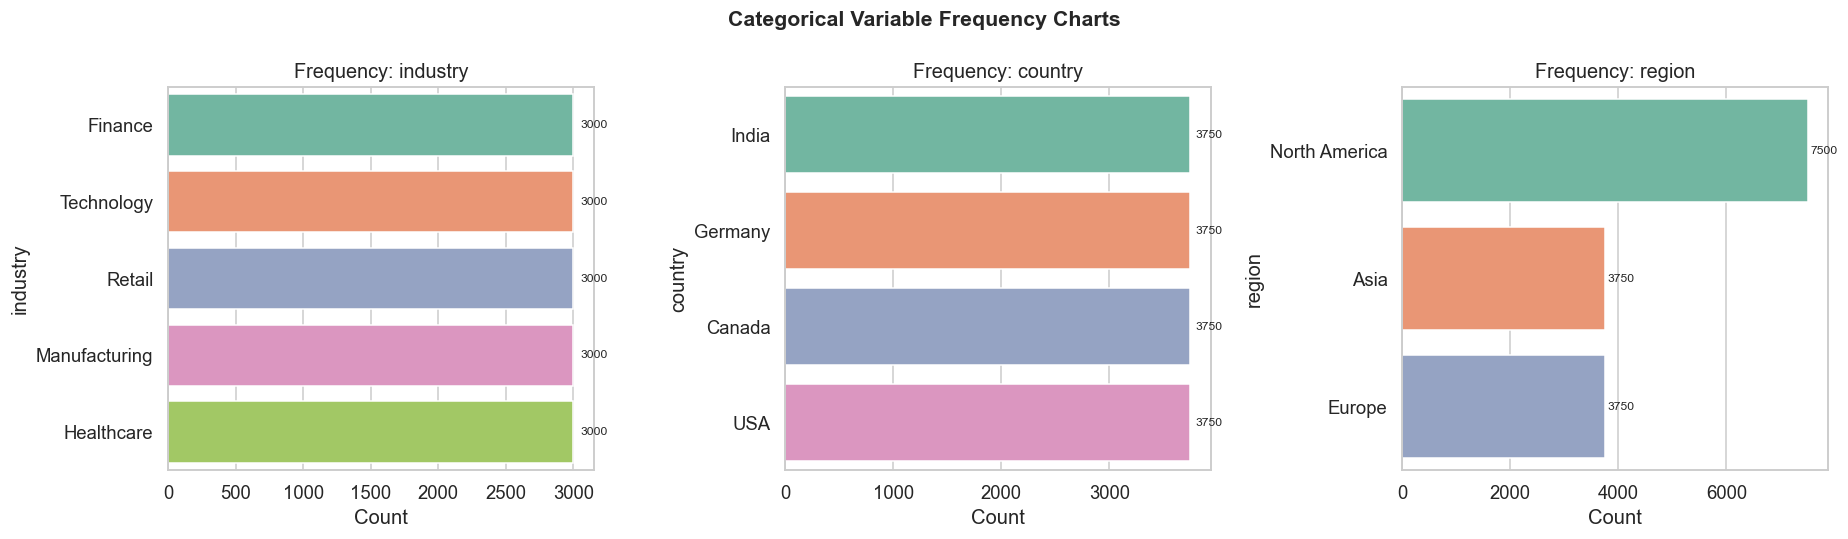

In [199]:
# ── Categorical Variable Frequency Analysis ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for i, col in enumerate(CAT_COLS):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order,
                  palette='Set2', ax=axes[i])
    axes[i].set_title(f'Frequency: {col}')
    axes[i].set_xlabel('Count')
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_width())}',
                         (p.get_width() + 50, p.get_y() + p.get_height() / 2),
                         va='center', fontsize=8)

plt.suptitle('Categorical Variable Frequency Charts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

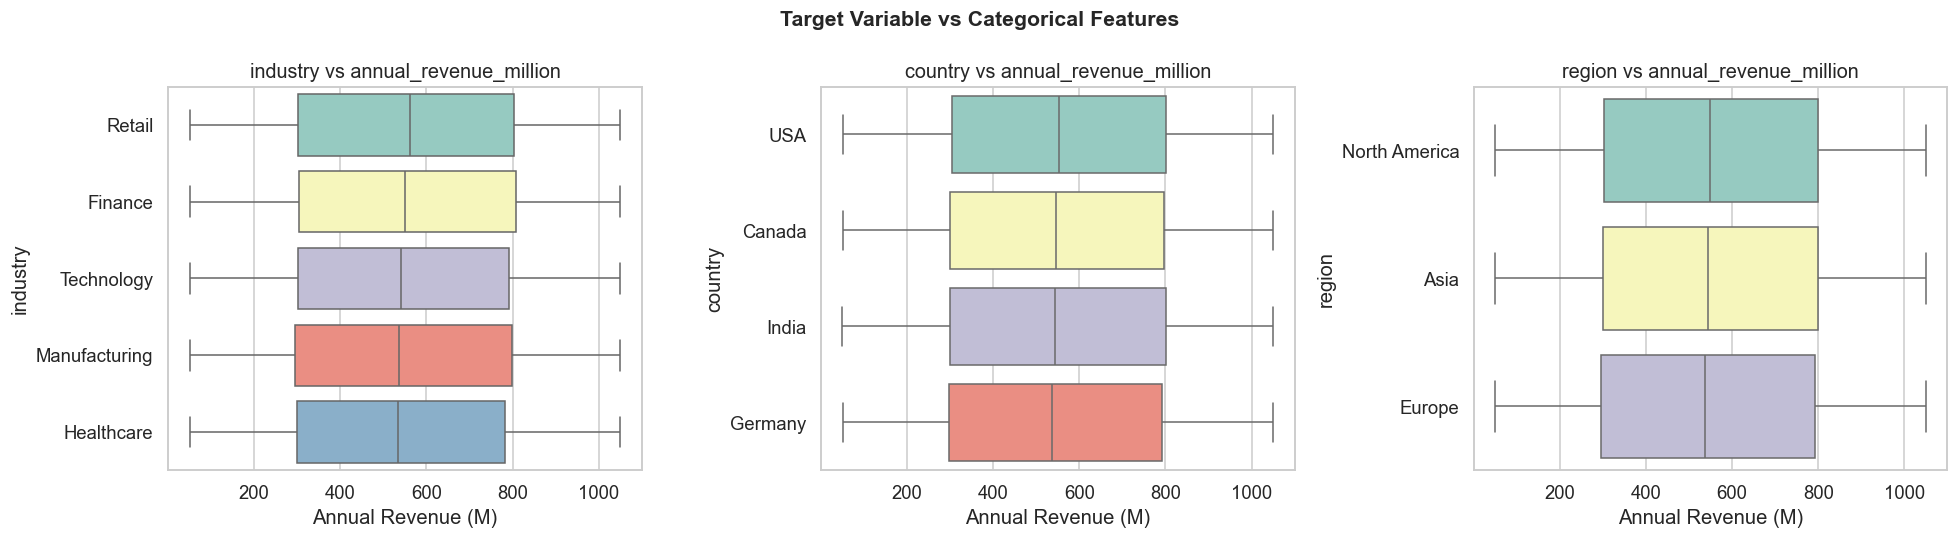

📌 ANOVA Test Results (categorical impact on revenue):
   industry    : F=1.03, p=0.3918 → ❌ Not significant
   country     : F=0.48, p=0.6935 → ❌ Not significant
   region      : F=0.49, p=0.6102 → ❌ Not significant


In [200]:
# ── Target vs Categorical Variables ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(CAT_COLS):
    order = df.groupby(col)[TARGET].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=TARGET, y=col, order=order,
                palette='Set3', ax=axes[i])
    axes[i].set_title(f'{col} vs {TARGET}')
    axes[i].set_xlabel('Annual Revenue (M)')

plt.suptitle('Target Variable vs Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ANOVA test
from scipy.stats import f_oneway
print("📌 ANOVA Test Results (categorical impact on revenue):")
for col in CAT_COLS:
    groups = [df[df[col] == cat][TARGET].values for cat in df[col].unique()]
    f_stat, p_val = f_oneway(*groups)
    sig = '✅ Significant' if p_val < 0.05 else '❌ Not significant'
    print(f"   {col:<12}: F={f_stat:.2f}, p={p_val:.4f} → {sig}")

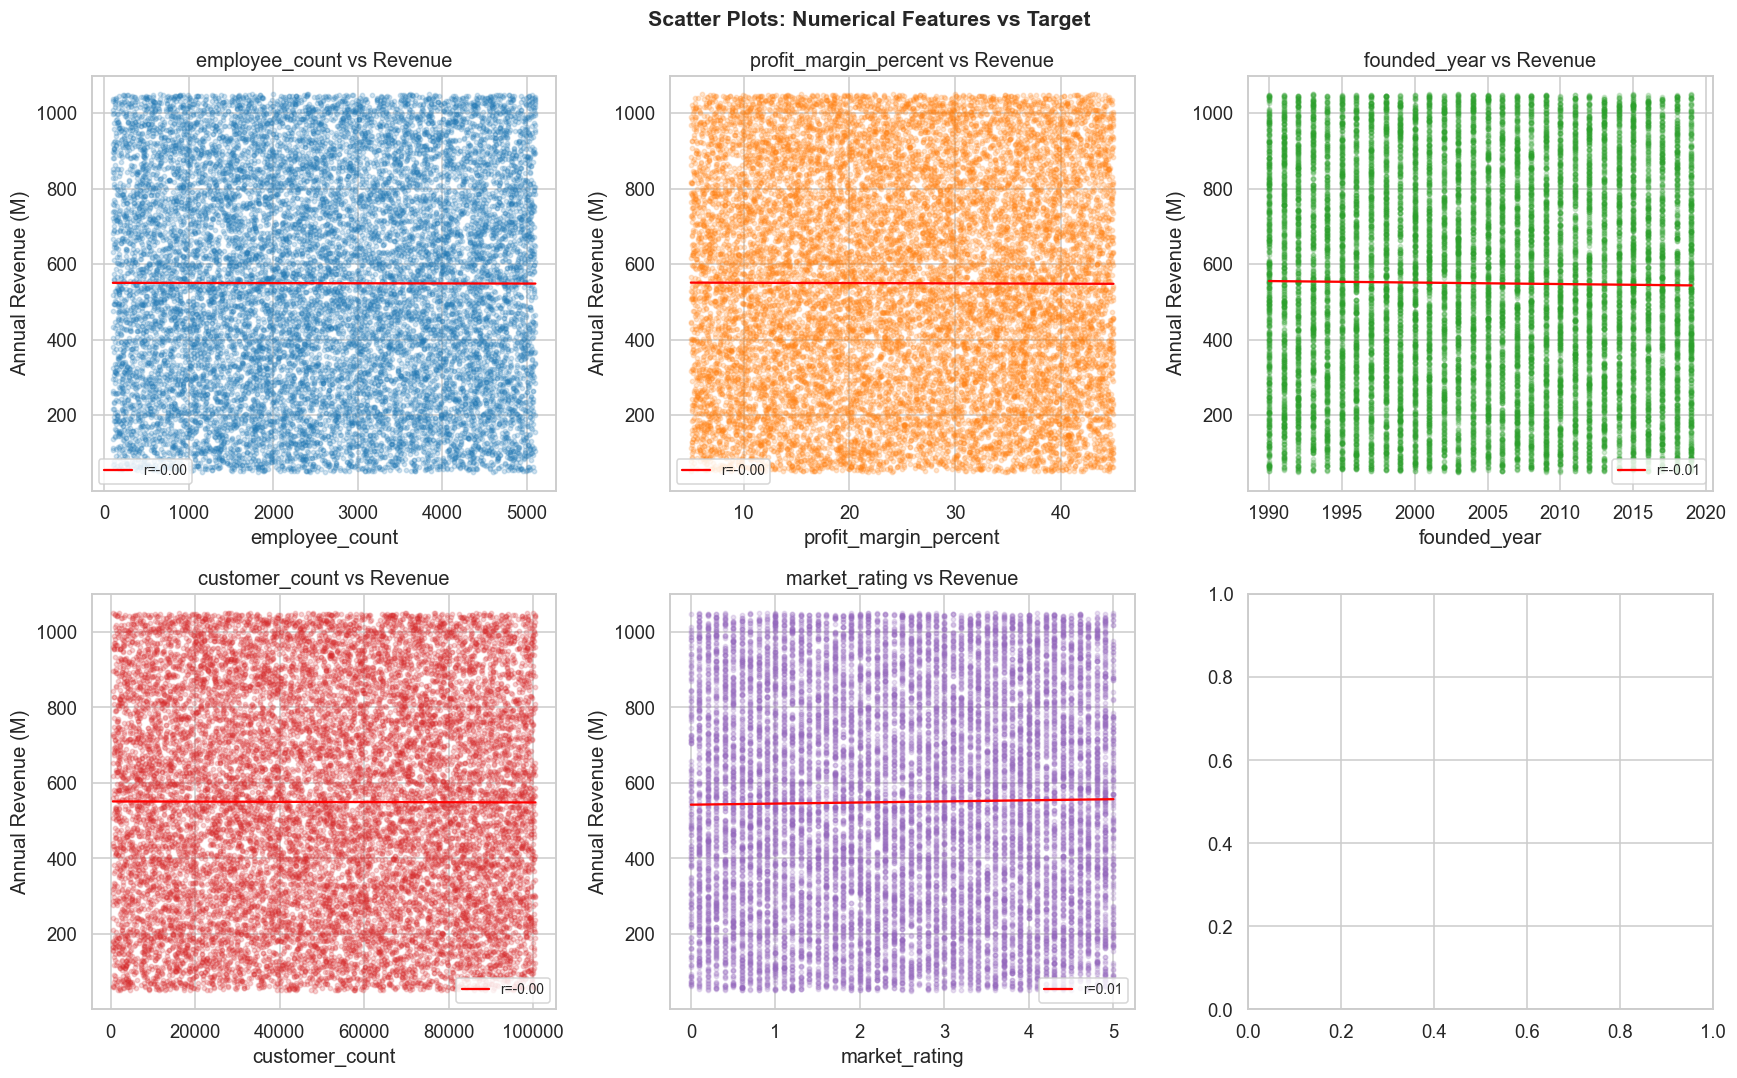

In [201]:
# ── Numerical vs Target (Scatter plots) ──────────────────────────────────────
num_feats = [c for c in NUM_COLS if c != TARGET]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_feats):
    axes[i].scatter(df[col], df[TARGET], alpha=0.2, s=8, color=sns.color_palette('tab10')[i])
    m, b, r, p, _ = stats.linregress(df[col], df[TARGET])
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='red', linewidth=1.5, label=f'r={r:.2f}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Annual Revenue (M)')
    axes[i].set_title(f'{col} vs Revenue')
    axes[i].legend(fontsize=9)

plt.suptitle('Scatter Plots: Numerical Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [202]:
# ── Average Revenue by Industry (interactive) ─────────────────────────────────
avg_rev = df.groupby('industry')[TARGET].mean().reset_index().sort_values(TARGET, ascending=False)

fig = px.bar(avg_rev, x='industry', y=TARGET,
             title='Average Annual Revenue by Industry',
             color=TARGET, color_continuous_scale='Greens',
             text=avg_rev[TARGET].round(1))
fig.update_traces(texttemplate='$%{text}M', textposition='outside')
fig.update_layout(height=420, xaxis_title='Industry', yaxis_title='Avg Revenue (M)')
fig.show()

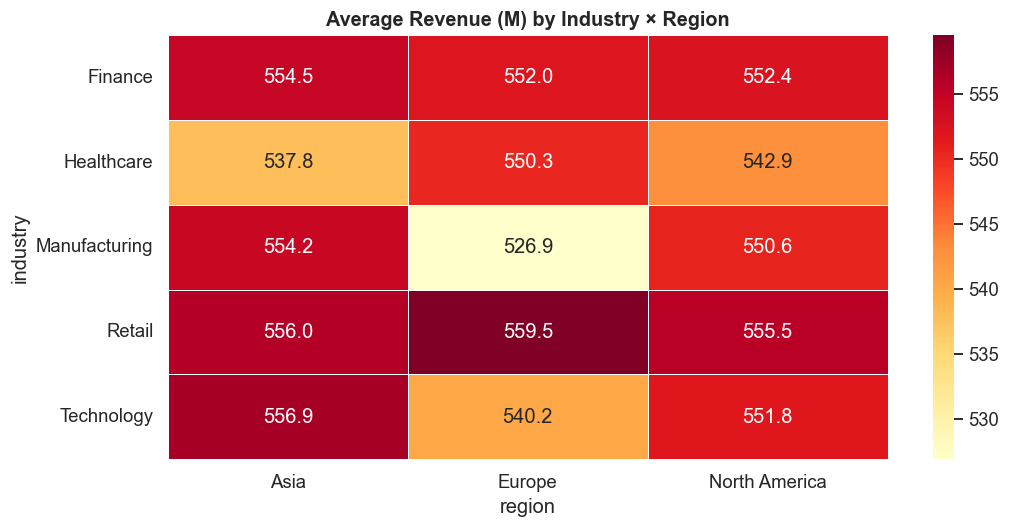

In [203]:
# ── Revenue by Region × Industry (heatmap) ────────────────────────────────────
pivot = df.pivot_table(values=TARGET, index='industry', columns='region', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Average Revenue (M) by Industry × Region', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
# PART 3: DATA PREPROCESSING

In [204]:
df_clean = df.copy()

# 1. Drop identifier columns not useful for modelling
df_clean.drop(columns=['id', 'company_name'], inplace=True)
print(f"Dropped: id, company_name")

# 2. Parse created_date and extract features
df_clean['created_date'] = pd.to_datetime(df_clean['created_date'], dayfirst=True, errors='coerce')
df_clean['record_year']  = df_clean['created_date'].dt.year
df_clean['record_month'] = df_clean['created_date'].dt.month
df_clean.drop(columns=['created_date'], inplace=True)
print(f"Parsed created_date → record_year, record_month")

# 3. Remove duplicates (0 found, but good practice)
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df_clean)}")

# 4. Handle missing values
missing = df_clean.isnull().sum().sum()
print(f"Missing values: {missing} ({'none – no imputation needed' if missing == 0 else 'imputing...'})")

# For safety: median impute any numeric NAs, mode impute categoricals
for col in df_clean.select_dtypes(include=np.number).columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f"\nShape after preprocessing: {df_clean.shape}")


Dropped: id, company_name
Parsed created_date → record_year, record_month
Duplicates removed: 0
Missing values: 0 (none – no imputation needed)

Shape after preprocessing: (15000, 11)


In [205]:
# ── Encode categorical variables ───────────────────────────────────────────────
le_encoders = {}

for col in ['industry', 'country', 'region']:
    le = LabelEncoder()
    df_clean[col + '_enc'] = le.fit_transform(df_clean[col])
    le_encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col} → {mapping}")

# Keep original categoricals for EDA reference; drop for modelling
df_model = df_clean.drop(columns=['industry', 'country', 'region']).copy()
print(f"\nModelling dataset shape: {df_model.shape}")
print(df_model.dtypes)

industry → {'Finance': np.int64(0), 'Healthcare': np.int64(1), 'Manufacturing': np.int64(2), 'Retail': np.int64(3), 'Technology': np.int64(4)}
country → {'Canada': np.int64(0), 'Germany': np.int64(1), 'India': np.int64(2), 'USA': np.int64(3)}
region → {'Asia': np.int64(0), 'Europe': np.int64(1), 'North America': np.int64(2)}

Modelling dataset shape: (15000, 11)
employee_count              int64
annual_revenue_million    float64
profit_margin_percent     float64
founded_year                int64
customer_count              int64
market_rating             float64
record_year                 int32
record_month                int32
industry_enc                int64
country_enc                 int64
region_enc                  int64
dtype: object


In [206]:
# ── Outlier treatment (Winsorization for the most skewed features) ─────────────
WINSORIZE_COLS = ['employee_count', 'customer_count', 'annual_revenue_million']

for col in WINSORIZE_COLS:
    q01 = df_model[col].quantile(0.01)
    q99 = df_model[col].quantile(0.99)
    n_clipped = ((df_model[col] < q01) | (df_model[col] > q99)).sum()
    df_model[col] = df_model[col].clip(lower=q01, upper=q99)
    print(f"Winsorized {col}: clipped {n_clipped} values to [{q01:.1f}, {q99:.1f}]")

print("\n✅ Winsorization applied at 1st and 99th percentiles to reduce extreme influence.")

Winsorized employee_count: clipped 299 values to [154.0, 5045.0]
Winsorized customer_count: clipped 300 values to [1580.9, 99430.0]
Winsorized annual_revenue_million: clipped 300 values to [60.8, 1041.7]

✅ Winsorization applied at 1st and 99th percentiles to reduce extreme influence.


---
# PART 4: FEATURE ENGINEERING

We create new features that may improve model predictive power by capturing interactions and domain knowledge.

In [207]:
# ── Derived features ──────────────────────────────────────────────────────────

# Revenue per employee – operational efficiency proxy
df_model['revenue_per_employee'] = df_model['annual_revenue_million'] / (df_model['employee_count'] + 1)

# Revenue per customer – customer monetisation proxy
df_model['revenue_per_customer'] = df_model['annual_revenue_million'] / (df_model['customer_count'] + 1)

# Company age – derived from founded_year
df_model['company_age'] = df_model['record_year'] - df_model['founded_year']
df_model['company_age'] = df_model['company_age'].clip(lower=0)  # no negative ages

# Customers per employee – scale indicator
df_model['customers_per_employee'] = df_model['customer_count'] / (df_model['employee_count'] + 1)

# Profit contribution – revenue × profit margin
df_model['absolute_profit'] = df_model['annual_revenue_million'] * df_model['profit_margin_percent'] / 100

# Interaction: employee × market_rating
df_model['employee_x_rating'] = df_model['employee_count'] * df_model['market_rating']

# Log transformation of highly skewed features (add 1 to avoid log(0))
df_model['log_employee_count']  = np.log1p(df_model['employee_count'])
df_model['log_customer_count']  = np.log1p(df_model['customer_count'])

# Binning founded_year into era buckets
bins   = [1900, 1980, 1995, 2005, 2015, 2030]
labels = ['Pre-1980', '1980-1994', '1995-2004', '2005-2014', '2015+']
df_model['founding_era'] = pd.cut(df_model['founded_year'], bins=bins, labels=labels, right=False)
df_model['founding_era_enc'] = LabelEncoder().fit_transform(df_model['founding_era'].astype(str))
df_model.drop(columns=['founding_era'], inplace=True)

new_features = ['revenue_per_employee', 'revenue_per_customer', 'company_age',
                'customers_per_employee', 'absolute_profit', 'employee_x_rating',
                'log_employee_count', 'log_customer_count', 'founding_era_enc']
print(f"✅ {len(new_features)} new features engineered:")
for f in new_features:
    print(f"   • {f}")
print(f"\nDataset shape after feature engineering: {df_model.shape}")

✅ 9 new features engineered:
   • revenue_per_employee
   • revenue_per_customer
   • company_age
   • customers_per_employee
   • absolute_profit
   • employee_x_rating
   • log_employee_count
   • log_customer_count
   • founding_era_enc

Dataset shape after feature engineering: (15000, 20)


---
# PART 5: FEATURE SELECTION



In [208]:
LEAK_FEATURES = ['revenue_per_employee', 'revenue_per_customer', 'absolute_profit']
FEATURE_COLS  = [c for c in df_model.columns
                 if c not in [TARGET] + LEAK_FEATURES]

X = df_model[FEATURE_COLS].copy()
y = df_model[TARGET].copy()

print(f"Features used for selection ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Features used for selection (16): ['employee_count', 'profit_margin_percent', 'founded_year', 'customer_count', 'market_rating', 'record_year', 'record_month', 'industry_enc', 'country_enc', 'region_enc', 'company_age', 'customers_per_employee', 'employee_x_rating', 'log_employee_count', 'log_customer_count', 'founding_era_enc']


In [209]:
# ── 1. Variance Threshold ──────────────────────────────────────────────────────
from sklearn.feature_selection import VarianceThreshold
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X)
low_var = X.columns[~selector_var.get_support()].tolist()
print(f"Low-variance features (dropped): {low_var if low_var else 'None – all retained'}")

Low-variance features (dropped): None – all retained


In [210]:
# ── 2. Correlation with target ────────────────────────────────────────────────
corr_target = X.corrwith(y).abs().sort_values(ascending=False)
print("Feature correlations with target:")
print(corr_target.to_string())

Feature correlations with target:
market_rating             0.014639
founding_era_enc          0.013800
founded_year              0.011818
company_age               0.011180
record_year               0.008484
record_month              0.007687
country_enc               0.007659
customers_per_employee    0.005555
employee_x_rating         0.005552
industry_enc              0.003869
log_customer_count        0.003565
profit_margin_percent     0.003105
log_employee_count        0.002881
customer_count            0.002684
employee_count            0.002040
region_enc                0.000345


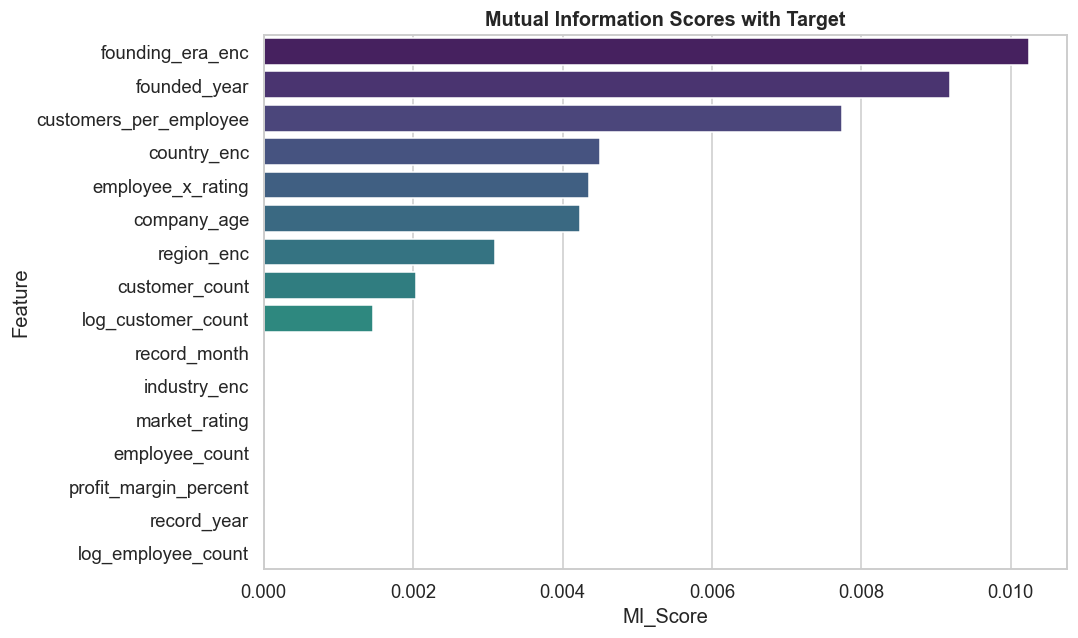

               Feature  MI_Score
      founding_era_enc  0.010247
          founded_year  0.009193
customers_per_employee  0.007735
           country_enc  0.004502
     employee_x_rating  0.004357
           company_age  0.004238
            region_enc  0.003097
        customer_count  0.002033
    log_customer_count  0.001469
          record_month  0.000000
          industry_enc  0.000000
         market_rating  0.000000
        employee_count  0.000000
 profit_margin_percent  0.000000
           record_year  0.000000
    log_employee_count  0.000000


In [211]:
# ── 3. Mutual Information ──────────────────────────────────────────────────────
mi_scores = mutual_info_regression(X, y, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI_Score': mi_scores})\
          .sort_values('MI_Score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=mi_df, x='MI_Score', y='Feature', palette='viridis', ax=ax)
ax.set_title('Mutual Information Scores with Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(mi_df.to_string(index=False))

In [ ]:
# ── 4. RFE with Random Forest ──────────────────────────────────────────────────
rfe_model = RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1)
rfe = RFE(estimator=rfe_model, n_features_to_select=10, step=1)
rfe.fit(X, y)

rfe_selected = X.columns[rfe.support_].tolist()
print(f"RFE selected features ({len(rfe_selected)}):")
for f in rfe_selected:
    print(f"   • {f}")

In [ ]:
# ── Final feature set ──────────────────────────────────────────────────────────
# Union of top-MI features and RFE features
TOP_MI = mi_df.head(10)['Feature'].tolist()
FINAL_FEATURES = list(set(rfe_selected + TOP_MI))

print(f"Final feature set ({len(FINAL_FEATURES)} features):")
for f in sorted(FINAL_FEATURES):
    print(f"   {f}")

X_final = X[FINAL_FEATURES].copy()

---
# PART 6: MODELLING STRATEGY

In [ ]:
# ── Train/Test split + scaling ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = RobustScaler()   # RobustScaler handles outliers better than StandardScaler
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")

In [ ]:
# ── Define models ──────────────────────────────────────────────────────────────
models = {
    'Linear Regression':      LinearRegression(),
    'Decision Tree':          DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
}


print(f"Registered {len(models)} models for training.")

In [ ]:
# ── Train + evaluate all models ────────────────────────────────────────────────
import time

results = []
trained_models = {}

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

for name, model in models.items():
    Xtr = X_train_sc if name in SCALE_MODELS else X_train.values
    Xte = X_test_sc  if name in SCALE_MODELS else X_test.values

    t0 = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - t0

    y_pred  = model.predict(Xte)
    y_pred_tr = model.predict(Xtr)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    _mape = mape(y_test.values, y_pred)

    # 5-fold CV on training data
    Xcv = X_train_sc if name in SCALE_MODELS else X_train.values
    cv_scores = cross_val_score(model, Xcv, y_train, cv=5,
                                scoring='r2', n_jobs=-1)

    trained_models[name] = model
    results.append({
        'Model': name,
        'R²':    round(r2, 4),
        'RMSE':  round(rmse, 2),
        'MAE':   round(mae, 2),
        'MAPE%': round(_mape, 2),
        'CV_R²_Mean': round(cv_scores.mean(), 4),
        'CV_R²_Std':  round(cv_scores.std(), 4),
        'Train_Time_s': round(train_time, 2),
    })
    print(f"  [{name:<22}] R²={r2:.4f} | RMSE={rmse:.2f} | MAE={mae:.2f} | "
          f"CV_R²={cv_scores.mean():.4f}±{cv_scores.std():.4f}")

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
print("\nAll models trained ✅")

In [ ]:
# ── Prediction vs Actual plots for top 4 models ────────────────────────────────
top4 = results_df.head(2)['Model'].tolist()
fig, axes = plt.subplots(2, figsize=(14, 10))
axes = axes.flatten()

for i, name in enumerate(top4):
    model = trained_models[name]
    Xte = X_test_sc if name in SCALE_MODELS else X_test.values
    y_pred = model.predict(Xte)

    axes[i].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
    mn, mx = y_test.min(), y_test.max()
    axes[i].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
    r2 = r2_score(y_test, y_pred)
    axes[i].set_title(f'{name}  (R²={r2:.4f})')
    axes[i].set_xlabel('Actual Revenue (M)')
    axes[i].set_ylabel('Predicted Revenue (M)')
    axes[i].legend(fontsize=8)

plt.suptitle('Actual vs Predicted – 2 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Base model
dt = DecisionTreeRegressor(random_state=RANDOM_STATE)

# Hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 8, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid Search
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit model
dt_grid.fit(X_train, y_train)

# Best model
best_dt = dt_grid.best_estimator_

print("Best Parameters:")
print(dt_grid.best_params_)

print("\nBest Cross-Validation R²:")
print(round(dt_grid.best_score_, 4))

# Predictions
dt_tuned_pred = best_dt.predict(X_test)

# Evaluation
r2 = r2_score(y_test, dt_tuned_pred)
rmse = np.sqrt(mean_squared_error(y_test, dt_tuned_pred))
mae = mean_absolute_error(y_test, dt_tuned_pred)

print("\nTuned Decision Tree Performance")
print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")

---
# PART 7: MODEL INTERPRETATION

We interpret the best model using Feature Importance, SHAP analysis, and Permutation Importance.

In [ ]:
# Select best model (highest R² from results_df)
best_model_name = results_df.iloc[0]['Model']
best_model      = trained_models[best_model_name]
print(f"Best model: {best_model_name}")

In [ ]:
# ── Feature Importance (tree-based) ───────────────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    fi_df = pd.DataFrame({
        'Feature':    FINAL_FEATURES,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=fi_df, x='Importance', y='Feature',
                palette='flare', ax=ax)
    ax.set_title(f'Feature Importance – {best_model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(fi_df.to_string(index=False))
else:
    print(f"Model {best_model_name} has no built-in feature_importances_. Skipping.")

In [ ]:
perm = permutation_importance(
    best_dt,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    'Feature': FINAL_FEATURES,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False)

In [ ]:
# ── Partial Dependence Plots (top 4 features) ──────────────────────────────────
top_features = perm_df.head(4)['Feature'].tolist()
top_indices  = [FINAL_FEATURES.index(f) for f in top_features]

fig, ax = plt.subplots(figsize=(14, 5))
PartialDependenceDisplay.from_estimator(
    best_dt, X_train, features=top_indices,
    feature_names=FINAL_FEATURES,
    ax=ax, n_cols=4
)
plt.suptitle('Partial Dependence Plots – Top 4 Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# PART 8: MODEL COMPARISON

A comprehensive comparison table and visualisation ranking all models.

In [ ]:

# ── Add tuned model results ──────────────────────────────────────────────────

tuned_rows = []

# Tuned Decision Tree
tuned_rows.append({
    'Model': 'Decision Tree (Tuned)',
    'R²': round(r2_score(y_test, dt_tuned_pred), 4),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, dt_tuned_pred)), 2),
    'MAE': round(mean_absolute_error(y_test, dt_tuned_pred), 2),
    'MAPE%': round(mape(y_test.values, dt_tuned_pred), 2),
    'CV_R²_Mean': round(dt_grid.best_score_, 4),
    'CV_R²_Std': '-',
    'Train_Time_s': '-'
})

# Combine original and tuned model results
full_results = pd.concat(
    [results_df, pd.DataFrame(tuned_rows)],
    ignore_index=True
).sort_values('R²', ascending=False).reset_index(drop=True)

full_results.index += 1
full_results.index.name = 'Rank'

print("\n📊 COMPLETE MODEL COMPARISON TABLE\n")
print(full_results.to_string())


In [ ]:
# ── R² Comparison Bar Chart ────────────────────────────────────────────────────
plot_df = full_results[['Model', 'R²', 'RMSE']].head(11).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R²
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(plot_df))]
axes[0].barh(plot_df['Model'][::-1], plot_df['R²'][::-1], color=colors[::-1])
axes[0].set_xlabel('R²')
axes[0].set_title('R² Score Comparison', fontweight='bold')
axes[0].axvline(x=0.9, color='red', linestyle='--', linewidth=1, label='R²=0.90')
axes[0].legend()

# RMSE
axes[1].barh(plot_df['Model'][::-1], plot_df['RMSE'][::-1], color='coral')
axes[1].set_xlabel('RMSE (lower is better)')
axes[1].set_title('RMSE Comparison', fontweight='bold')

plt.suptitle('Model Performance Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

In [ ]:
new_data = X_test.iloc[[0]]

prediction = best_dt.predict(new_data)

print("Predicted Annual Revenue (Million USD):", prediction[0])

In [ ]:
new_data = X_test.iloc[:5]

predictions = best_dt.predict(new_data)

print(predictions)

In [ ]:
# Predict on unseen sample
best_dt.predict(new_data)

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.iloc[:10].values,
    'Predicted': best_dt.predict(X_test.iloc[:10])
})

print(comparison)